In [3]:
#!/usr/bin/env python3
"""
main.py
=======
Entry point and configuration hub for the UNO-card symbol-candidate
preprocessing pipeline.
 
Usage:
    python main.py
 
Pipeline:
    1. Load image(s) from IMAGE_SOURCE            (io_utils.load_images_from)
       -- IMAGE_SOURCE may be a directory OR a single image file.
    2. Run the preprocessing chain on the batch   (preprocess_utils.preprocess_image)
       threshold -> morphology -> edges -> tile_image -> tile_selection
    3. Persist the resulting symbol_candidates    (io_utils.save_images_to)
"""
 
from __future__ import annotations
 
from typing import Any, Dict
 
from io_utils import load_images_from, save_images_to
from preprocess_utils import preprocess_image
 
 
# ============================================================================
# CONFIGURATION
# ============================================================================
 
# ---- I/O ----
# IMAGE_SOURCE may be either a directory (batch mode) or a single image file
# (single-image mode). When it's a directory, IMAGE_GLOB filters its contents;
# when it's a file, IMAGE_GLOB is ignored.
IMAGE_SOURCE = "./data/train_images/L1000770.jpg"   # single-image mode
# IMAGE_SOURCE = "./data/train_images"              # batch mode
OUTPUT_DIR  = "./tile"                              # candidate tiles go here
IMAGE_GLOB  = "*.jpg"                               # used only in batch mode
SAVE_FORMAT = "png"                                 # extension for saved tiles
 
# ---- diagnostics ----
SHOW_PLOTS = True   # master toggle: True renders every stage's matplotlib
                    # figure for every image; False runs silently.
 
# ---- thresholding (HSV white-bg filter) ----
SAT_MAX = 40        # HSV saturation below this -> candidate background
VAL_MIN = 180       # HSV value above this      -> candidate background
 
# ---- morphology / mask cleanup ----
MEDIAN_KSIZE  = 3   # 0 to skip
OPEN_KSIZE    = 3   # 0 to skip
CLOSE_KSIZE   = 3   # 0 to skip
MIN_BLOB_AREA = 20  # 0 to skip
SMOOTH_KSIZE  = 5   # Gaussian-then-rethreshold contour smoothing; 0 to skip
 
# ---- edges ----
SOBEL_KSIZE = 3
 
# ---- tiling geometry ----
TILE_SIZE = 75        # square window in px
OVERLAP   = 2.0 / 3.0 # fractional overlap -> stride = round(TILE_SIZE * (1 - OVERLAP))
 
# ---- tile selection ----
EDGE_THRESH    = 20   # pixel intensity above which a Sobel pixel is "edge"
EDGE_KEEP_FRAC = 0.10 # keep tile when edge-pixel fraction >= this
 
# ---- reproducibility ----
SEED = 42
 
 
# Bundle the stage overrides we want preprocess_image to use.
PIPELINE_KW: Dict[str, Any] = dict(
    sat_max=SAT_MAX, val_min=VAL_MIN,
    median_ksize=MEDIAN_KSIZE, open_ksize=OPEN_KSIZE,
    close_ksize=CLOSE_KSIZE, min_blob_area=MIN_BLOB_AREA,
    smooth_ksize=SMOOTH_KSIZE,
    ksize=SOBEL_KSIZE,
    tile_size=TILE_SIZE, overlap=OVERLAP,
    edge_thresh=EDGE_THRESH, edge_keep_frac=EDGE_KEEP_FRAC,
    seed=SEED,
)
 

loaded 1 image(s) from ./data/train_images/L1000770.jpg

=== preprocess_image: L1000770 ===


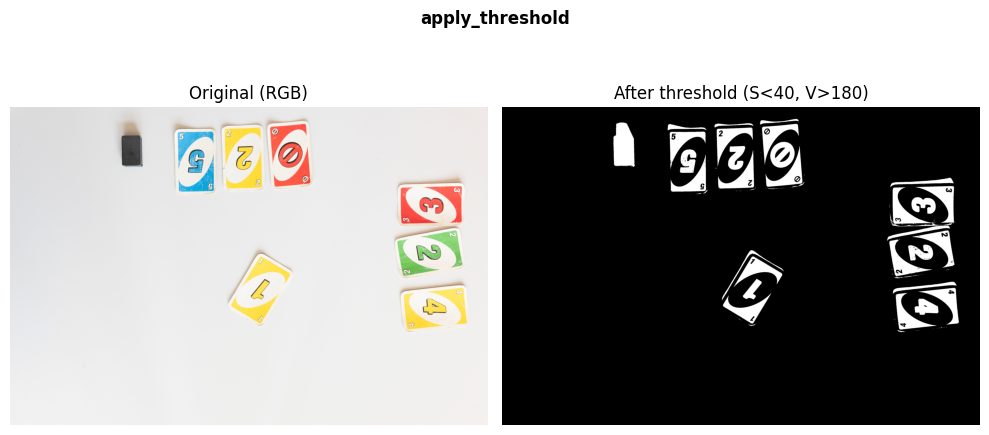

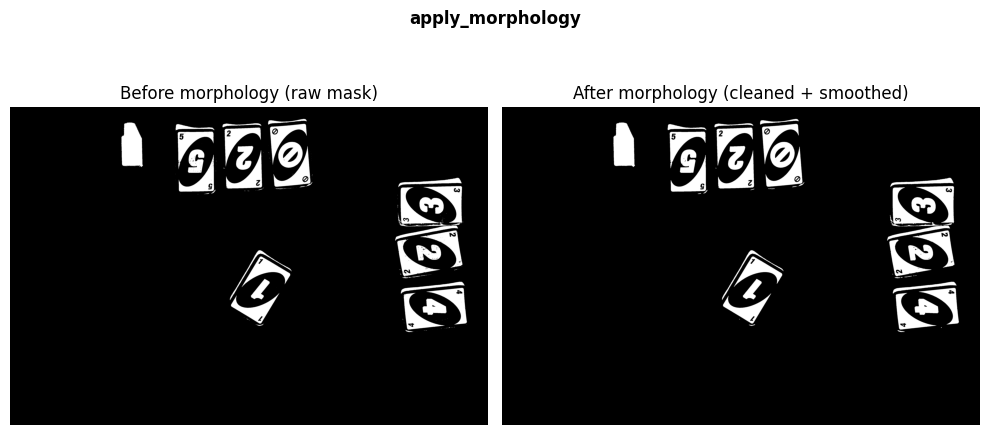

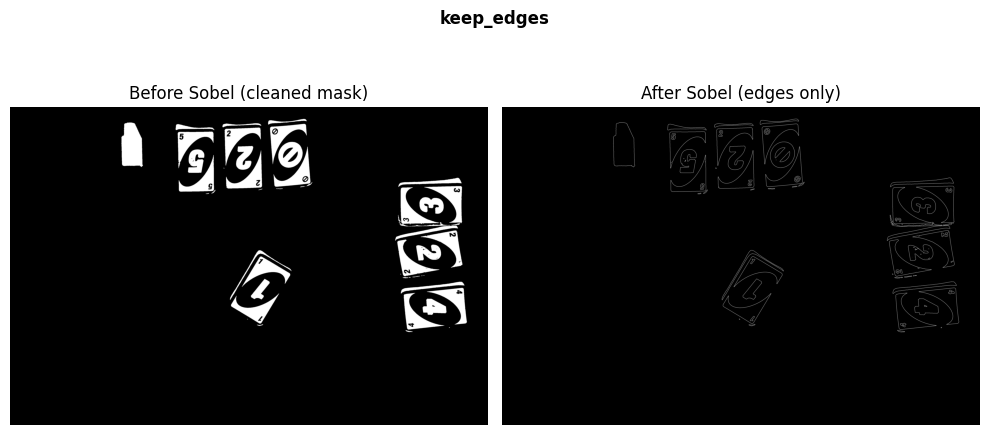

tile_selection
--------------------------------------------------
  parameters    : edge_thresh=20, edge_keep_frac=10.00%
  geometry      : 158 cols x 105 rows = 16590 tiles (tile 75px, stride 25px)
  result        : kept 186 / discarded 16404 (keep ratio 0.011)
  kept edge-frac: min=0.100 mean=0.124 max=0.221
--------------------------------------------------


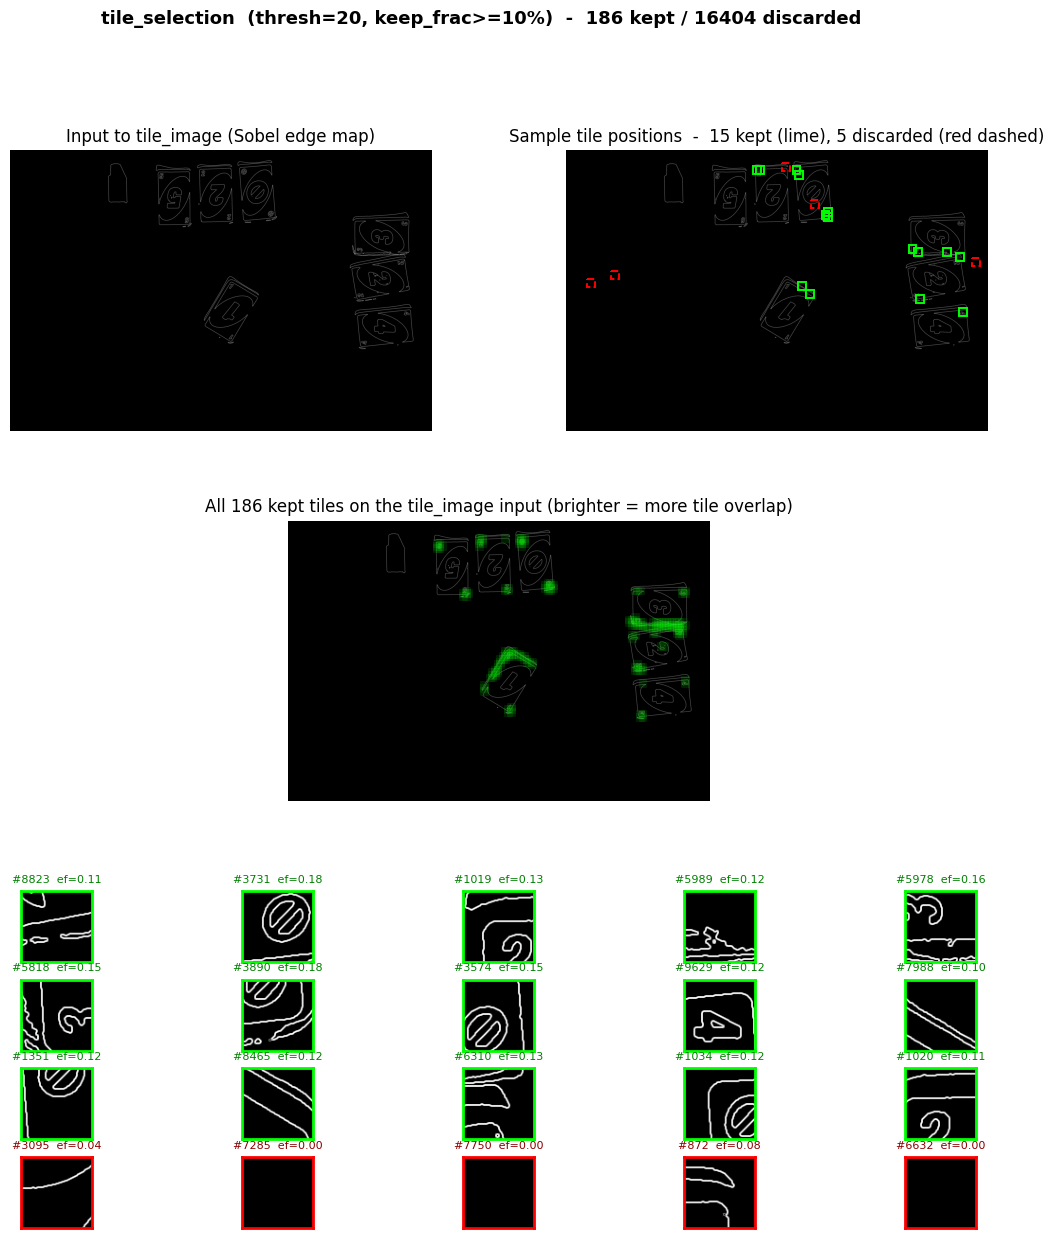


=== save phase ===
saved 186 candidate tile(s) to ./tile\L1000770/

Done. 186 candidate tile(s) across 1 image(s).


In [4]:
images = load_images_from(IMAGE_SOURCE, IMAGE_GLOB)

results = preprocess_image(images, show_plots=SHOW_PLOTS, **PIPELINE_KW)

print("\n=== save phase ===")
for filename, symbol_candidates in results.items():
    save_images_to(OUTPUT_DIR, filename, symbol_candidates,
                    fmt=SAVE_FORMAT)

total = sum(len(v) for v in results.values())
print(f"\nDone. {total} candidate tile(s) across {len(results)} image(s).")